# Low-Level Orchestration using LangGraph

_Experimenting advanced capablities of LangGraph to support building long-running and stateful agents._

Demonstrate core LangGraph capabilities in a single, easy-to-understand workflow by building a stateful approval copilot/assistant that processes assignment extension requests and routes them through policy checks, risk scoring, optional human review, and final decision generatio leveraging LangGraph's advanced capabilties such as Durable execution (checkpointing), Fault tolerance (retries, timeout simulation, structured error handling), Memory (short-term state + long-term per-student history), Event streaming, Interrupts and Human-in-the-loop.

In [ ]:
# Imports packages

import random
import sqlite3
import time
import uuid
from pprint import pprint
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, Literal, Optional, TypedDict
from IPython.display import Image, display

from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import Command, interrupt
from langchain_core.runnables import RunnableConfig


## Configuration

In [2]:
class LabSettings(TypedDict):
    random_seed: int                    # For reproducibility
    policy_failure_probability: float   # Simulates policy service failure
    policy_max_delay_seconds: float     # Time taken for policy service to complete processing
    policy_timeout_seconds: float       # Timeout if the policy service does not respond within a given time period
    policy_max_retries: int             # Number of times the system should try accessing policy service upon failure


LAB_SETTINGS: LabSettings = {
    "random_seed": 42,
    "policy_failure_probability": 0.30,
    "policy_max_delay_seconds": 2.00,
    "policy_timeout_seconds": 1.00,
    "policy_max_retries": 2,
}

random.seed(LAB_SETTINGS["random_seed"])

## Tools

In [3]:
def get_policy() -> dict[str, Any]:
    """Simulates a flaky external service with random delay and transient failures."""

    simulated_delay = random.uniform(0, LAB_SETTINGS["policy_max_delay_seconds"])   # Random delay
    time.sleep(simulated_delay)

    if simulated_delay > LAB_SETTINGS["policy_timeout_seconds"]:
        raise TimeoutError(
            f"Policy service timed out after {simulated_delay:.2f}s "
            f"(limit={LAB_SETTINGS['policy_timeout_seconds']:.2f}s)."
        )

    if random.random() < LAB_SETTINGS["policy_failure_probability"]:                # Transient error
        raise RuntimeError("Transient policy service failure.")

    allowed_reasons = {
        "medical",
        "family_emergency",
        "official_event",
        "technical_issue",
    }

    max_allowed_days = 7

    return {
        "allowed_reasons": sorted(allowed_reasons),
        "max_allowed_days": max_allowed_days,
    }

## Graph Design

### State of the Graph

A shared state to be used by all the nodes in the graph.

In [4]:
RiskLevel = Literal["low", "medium", "high"]
Decision = Literal["approve", "deny", "modify"]

class ExtensionRequestState(TypedDict):
    # Metadata
    request_id: str
    timestamp_utc: str

    # Input (extension request) payload
    student_id: str
    student_name: str
    assignment_id: str
    reason: str
    requested_days: int

    # Policy tool output
    policy_result: dict[str, Any]

    # Risk + recommendation
    risk_level: RiskLevel
    risk_score: float
    risk_factors: list[str]
    model_recommendation: Decision
    recommendation_rationale: str

    # Reliability metadata
    retry_count: int
    timeout_flag: bool
    error_message: str

    # Human-in-the-Loop
    human_review_required: bool
    human_review_payload: dict[str, Any]
    human_action: Decision
    human_comment: str
    modified_days: Optional[int]

    # Final output
    decision: Decision
    approved_days: int
    final_message: str

    # Routing control
    next_step: str

### Functions/Runables for Graph Nodes

In [5]:
def extension_request(state: ExtensionRequestState) -> ExtensionRequestState:
    return {
        "request_id": state.get("request_id", str(uuid.uuid4())),
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "retry_count": 0,
        "timeout_flag": False,
        "error_message": "",
    }

def policy_lookup(state: ExtensionRequestState) -> ExtensionRequestState:
    retries = LAB_SETTINGS["policy_max_retries"]
    last_error: Optional[Exception] = None

    for attempt in range(retries + 1):
        try:
            policy = get_policy()
            return {
                "policy_result": policy,
                "retry_count": attempt,
                "timeout_flag": False,
                "error_message": "",
                "next_step": "score_risk", # Explicitly overwrite any previous routing hint.
            }
        except TimeoutError as ex:
            last_error = ex
            if attempt == retries:
                return {
                    "retry_count": attempt,
                    "timeout_flag": True,
                    "error_message": str(ex),
                    "next_step": "handle_error",
                }
        except Exception as ex:  # pylint: disable=broad-except
            last_error = ex
            if attempt == retries:
                return {
                    "retry_count": attempt,
                    "timeout_flag": False,
                    "error_message": str(ex),
                    "next_step": "handle_error",
                }

    return {
        "error_message": str(last_error) if last_error else "Unknown policy lookup error.",
        "next_step": "handle_error",
    }

def score_risk(state: ExtensionRequestState) -> ExtensionRequestState:
    policy = state["policy_result"]
    max_days = int(policy["max_allowed_days"])

    score = 0.0
    factors: list[str] = []

    if state["requested_days"] > max_days:
        score += 0.55
        factors.append("Requested days is above policy limit.")

    allowed_reasons = set(policy["allowed_reasons"])
    if state["reason"] not in allowed_reasons:
        score += 0.45
        factors.append("Reason is not in standard policy list.")

    if score < 0.30:
        risk: RiskLevel = "low"
    elif score < 0.70:
        risk = "medium"
    else:
        risk = "high"

    return {
        "risk_score": round(score, 2),
        "risk_level": risk,
        "risk_factors": factors,
    }

def draft_recommendation(state: ExtensionRequestState) -> ExtensionRequestState:
    risk = state["risk_level"]
    requested_days = state["requested_days"]
    max_allowed_days = int(state["policy_result"]["max_allowed_days"])

    if risk == "low":
        recommendation: Decision = "approve"
        rationale = "Low risk request. Recommend approval as requested."
    elif risk == "medium":
        recommendation = "modify"
        suggested_days = min(requested_days, max_allowed_days)
        rationale = f"Medium risk request. Recommend instructor review with possible modification to {suggested_days} day(s)."
    else:
        recommendation = "deny"
        rationale = "High risk request. Recommend denial."

    return {
        "model_recommendation": recommendation,
        "recommendation_rationale": rationale,
    }

def route_decision(state: ExtensionRequestState) -> ExtensionRequestState:
    risk = state["risk_level"]
    requires_human = risk in {"medium", "high"}

    payload = {
        "request_id": state["request_id"],
        "student_id": state["student_id"],
        "student_name": state["student_name"],
        "assignment_id": state["assignment_id"],
        "requested_days": state["requested_days"],
        "risk_level": state["risk_level"],
        "risk_score": state["risk_score"],
        "risk_factors": state["risk_factors"],
        "model_recommendation": state["model_recommendation"],
        "recommendation_rationale": state["recommendation_rationale"],
    }

    return {
        "human_review_required": requires_human,
        "human_review_payload": payload,
        "next_step": "human_review" if requires_human else "finalize_decision",
    }


def human_review(state: ExtensionRequestState) -> ExtensionRequestState:
    # Terminates execution
    review = interrupt(
        {
            "type": "human_review",
            "message": "Instructor decision required.",
            "allowed_actions": ["approve", "deny", "modify"],
            "context": state["human_review_payload"],
            "example_resume_payload": {
                "action": "modify",
                "modified_days": 3,
                "comment": "Approved with reduced days.",
            },
        }
    )

    return {
        "human_action": review.get("action", state["model_recommendation"]),
        "human_comment": review.get("comment", ""),
        "modified_days": review.get("modified_days"),
    }

def finalize_decision(state: ExtensionRequestState) -> ExtensionRequestState:
    if state.get("human_review_required"):
        action = state.get("human_action", state["model_recommendation"])
    else:
        action = state["model_recommendation"]

    if action == "approve":
        approved_days = state["requested_days"]
    elif action == "modify":
        approved_days = int(state.get("modified_days") or state["policy_result"]["max_allowed_days"])
    else:
        approved_days = 0

    final_message = f"Decision: {action.upper()} | Requested: {state['requested_days']} day(s) | Approved: {approved_days} day(s)."

    return {
        "decision": action,
        "approved_days": approved_days,
        "final_message": final_message,
    }

def handle_error(state: ExtensionRequestState) -> ExtensionRequestState:
    details = state.get("error_message")
    return {
        "decision": "deny",
        "approved_days": 0,
        "final_message": f"Request could not be processed safely. Details: {details}",
    }

### Building Graph

In [6]:
builder = StateGraph(ExtensionRequestState)

# Adding nodes

builder.add_node("extension_request", extension_request)
builder.add_node("policy_lookup", policy_lookup)
builder.add_node("score_risk", score_risk)
builder.add_node("draft_recommendation", draft_recommendation)
builder.add_node("route_decision", route_decision)
builder.add_node("human_review", human_review)
builder.add_node("finalize_decision", finalize_decision)
builder.add_node("handle_error", handle_error)

# Adding directed and conditional edges

builder.add_edge(START, "extension_request")
builder.add_edge("extension_request", "policy_lookup")

builder.add_conditional_edges(
    "policy_lookup",
    lambda _state: _state.get("next_step", "score_risk"),
    {
        "score_risk": "score_risk",
        "handle_error": "handle_error",
    },
)

builder.add_edge("score_risk", "draft_recommendation")
builder.add_edge("draft_recommendation", "route_decision")

builder.add_conditional_edges(
    "route_decision",
    lambda _state: _state["next_step"],
    {
        "human_review": "human_review",
        "finalize_decision": "finalize_decision",
    },
)

builder.add_edge("human_review", "finalize_decision")
builder.add_edge("finalize_decision", END)
builder.add_edge("handle_error", END)

# File-backed SQLite checkpointer for durable execution across kernel restarts.
CHECKPOINT_DB_PATH = Path("workflow_artifacts/langgraph_checkpoints.sqlite")
CHECKPOINT_DB_PATH.parent.mkdir(parents=True, exist_ok=True)

checkpoint_conn = sqlite3.connect(str(CHECKPOINT_DB_PATH), check_same_thread=False)
checkpoint_conn.execute("PRAGMA journal_mode=WAL;")
checkpoint_conn.execute("PRAGMA synchronous=NORMAL;")

checkpointer = SqliteSaver(conn=checkpoint_conn)

graph = builder.compile(checkpointer=checkpointer)

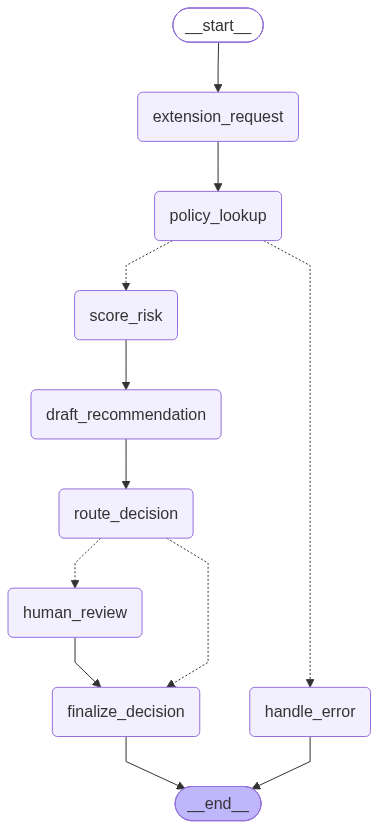

In [ ]:
# Renders the graph structure as a flowchart using Mermaid's external rendering endpoint that requires internet connectivity.

display(Image(graph.get_graph().draw_mermaid_png()))

## Graph Execution

### Graph Execution Helper Functions

In [7]:
def stream_request(initial_state: ExtensionRequestState, thread_id: Optional[str] = None) -> dict[str, Any]:
    """
    Run a request with event streaming.

    Returns a dict with:
    - thread_id
    - interrupted (bool)
    - interrupt_payload (if interrupted)
    - final_state (if completed)
    """

    thread_id = thread_id or f"thread-{uuid.uuid4()}"
    cfg: RunnableConfig = {"configurable": {"thread_id": thread_id}}

    print(f"\n=== STREAM START | thread_id={thread_id} ===")

    interrupted_payload = None
    final_state = None

    for event in graph.stream(initial_state, config=cfg, stream_mode="updates"):
        print(f"\nEvent:")
        pprint(event)

        # LangGraph interrupts are exposed under __interrupt__ in stream updates.
        if "__interrupt__" in event:
            interrupted_payload = event["__interrupt__"]
            print("\nExecution interrupted for human review.")
            break

    if interrupted_payload is None:
        final_state = graph.get_state(cfg).values
        print("\n=== STREAM COMPLETE ===")
        pprint({
            "decision": final_state.get("decision"),
            "approved_days": final_state.get("approved_days"),
            "final_message": final_state.get("final_message"),
        })

    return {
        "thread_id": thread_id,
        "interrupted": interrupted_payload is not None,
        "interrupt_payload": interrupted_payload,
        "final_state": final_state,
    }

### Graph Execution against Scenarios

**Scenario #1: Low Risk Request + Error Handling**

Low risk request is simulated over 
**(a)** extension reason from the allowed list and 
**(b)** extension period within the maximum limit.

At the same time error handling is simulated by introducing transient error in 
policy service oover **(a)** random failure and **(b)** delay (refer SETTINGS).

Consider executing the statement multiple times for error to introduced due to probabilistic uncertainty and observe output including final decision.

In [8]:
stream_request({
    "student_id": "S2001",
    "student_name": "Asha",
    "assignment_id": "A1",
    "reason": "medical",    # reason is from the allowed list
    "requested_days": 2,    # requested days below the max. limit
})


=== STREAM START | thread_id=thread-3f376c6e-371d-4dfe-aab4-450b70d180f5 ===

Event:
{'extension_request': {'error_message': '',
                       'request_id': 'e755a437-18ee-4760-a59c-80538664901f',
                       'retry_count': 0,
                       'timeout_flag': False,
                       'timestamp_utc': '2026-07-30T06:01:06.747381+00:00'}}

Event:
{'policy_lookup': {'error_message': '',
                   'next_step': 'score_risk',
                   'policy_result': {'allowed_reasons': ['family_emergency',
                                                         'medical',
                                                         'official_event',
                                                         'technical_issue'],
                                     'max_allowed_days': 7},
                   'retry_count': 0,
                   'timeout_flag': False}}

Event:
{'score_risk': {'risk_factors': [], 'risk_level': 'low', 'risk_score': 0.0}}

Event:
{'dr

{'thread_id': 'thread-3f376c6e-371d-4dfe-aab4-450b70d180f5',
 'interrupted': False,
 'interrupt_payload': None,
 'final_state': {'request_id': 'e755a437-18ee-4760-a59c-80538664901f',
  'timestamp_utc': '2026-07-30T06:01:06.747381+00:00',
  'student_id': 'S2001',
  'student_name': 'Asha',
  'assignment_id': 'A1',
  'reason': 'medical',
  'requested_days': 2,
  'policy_result': {'allowed_reasons': ['family_emergency',
    'medical',
    'official_event',
    'technical_issue'],
   'max_allowed_days': 7},
  'risk_level': 'low',
  'risk_score': 0.0,
  'risk_factors': [],
  'model_recommendation': 'approve',
  'recommendation_rationale': 'Low risk request. Recommend approval as requested.',
  'retry_count': 0,
  'timeout_flag': False,
  'error_message': '',
  'human_review_required': False,
  'human_review_payload': {'request_id': 'e755a437-18ee-4760-a59c-80538664901f',
   'student_id': 'S2001',
   'student_name': 'Asha',
   'assignment_id': 'A1',
   'requested_days': 2,
   'risk_level': 'l

**Scenario #2: Interrupt**

A medium/high risk request is simulated over **(a)** reason not from the allowed list and/or **(b)** requested extension is beyond the permitted limit causing processing to be terminated and requiring human-in-the-loop to review to resume the processing towards its completion.

NOTE: If error takes place due to purposely introduced transient error in policy service, try rerun the below statement multiple times till the service is interrupted as expected.

In [11]:
interrupt_state = stream_request({
    "student_id": "S1002",
    "student_name": "Rahul",
    "assignment_id": "A2",
    "reason": "personal_trip",  # reason is not from the allowed list
    "requested_days": 8,        # request is beyond the max. limit
})


=== STREAM START | thread_id=thread-df3f9a80-f6f6-4112-a6e6-54998f29d198 ===

Event:
{'extension_request': {'error_message': '',
                       'request_id': '8f38dbc4-342d-4eb3-912c-fd25ac59c954',
                       'retry_count': 0,
                       'timeout_flag': False,
                       'timestamp_utc': '2026-07-30T06:05:08.916274+00:00'}}

Event:
{'policy_lookup': {'error_message': '',
                   'next_step': 'score_risk',
                   'policy_result': {'allowed_reasons': ['family_emergency',
                                                         'medical',
                                                         'official_event',
                                                         'technical_issue'],
                                     'max_allowed_days': 7},
                   'retry_count': 0,
                   'timeout_flag': False}}

Event:
{'score_risk': {'risk_factors': ['Requested days is above policy limit.',
               

In [12]:
# Resumes an interrupted run with human input.

cfg: RunnableConfig = {"configurable": {"thread_id": interrupt_state["thread_id"]}}
resume_payload = {
    "action": "modify",
    "modified_days": 3,
    "comment": "Approved with reduced extension.",
}

print(f"\n=== RESUME START | thread_id={interrupt_state["thread_id"]} ===")
print("Resume payload:")
pprint(resume_payload)

for event in graph.stream(Command(resume=resume_payload), config=cfg, stream_mode="updates"):
    print("\nEvent:")
    pprint(event)

final_state = graph.get_state(cfg).values

print("\n=== RESUME COMPLETE ===")
pprint({
    "decision": final_state.get("decision"),
    "approved_days": final_state.get("approved_days"),
    "final_message": final_state.get("final_message"),
    "human_comment": final_state.get("human_comment"),
})


=== RESUME START | thread_id=thread-df3f9a80-f6f6-4112-a6e6-54998f29d198 ===
Resume payload:
{'action': 'modify',
 'comment': 'Approved with reduced extension.',
 'modified_days': 3}

Event:
{'human_review': {'human_action': 'modify',
                  'human_comment': 'Approved with reduced extension.',
                  'modified_days': 3}}

Event:
{'finalize_decision': {'approved_days': 3,
                       'decision': 'modify',
                       'final_message': 'Decision: MODIFY | Requested: 8 '
                                        'day(s) | Approved: 3 day(s).'}}

=== RESUME COMPLETE ===
{'approved_days': 3,
 'decision': 'modify',
 'final_message': 'Decision: MODIFY | Requested: 8 day(s) | Approved: 3 '
                  'day(s).',
 'human_comment': 'Approved with reduced extension.'}


**Scenario #3: Durable Execution**

This graph also uses a file-backed SQLite checkpointer. To test the persistance, consider

1. restarting the kernel after the graph execution termination while experimenting the previous scenario.
1. Re-run all definition cells so the graph is rebuilt.
2. Keep the same SQLite DB path.
3. Resume using the same `thread_id` used before the interrupt.